In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt


drive.mount('/content/drive')

In [ ]:
df_detail=pd.read_json("/content/drive/MyDrive/CS3244 Project/IMDB_movie_details.json", lines=True)
df_review=pd.read_json("/content/drive/MyDrive/CS3244 Project/IMDB_reviews.json", lines=True)

In [ ]:
df_review.head(3)

,review_date,movie_id,user_id,is_spoiler,review_text,rating,review_summary
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.
1,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.
2,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film


In [ ]:
df_detail.head(3)

,movie_id,plot_summary,duration,genre,rating,release_date,plot_synopsis
0,tt0105112,"Former CIA analyst, Jack Ryan is in England wi...",1h 57min,"[Action, Thriller]",6.9,1992-06-05,"Jack Ryan (Ford) is on a ""working vacation"" in..."
1,tt1204975,"Billy (Michael Douglas), Paddy (Robert De Niro...",1h 45min,[Comedy],6.6,2013-11-01,Four boys around the age of 10 are friends in ...
2,tt0243655,"The setting is Camp Firewood, the year 1981. I...",1h 37min,"[Comedy, Romance]",6.7,2002-04-11,


In [ ]:
df_merged = pd.merge(df_detail, df_review, on="movie_id", how="outer")
df_merged

,movie_id,plot_summary,duration,genre,rating_x,release_date,plot_synopsis,review_date,user_id,is_spoiler,review_text,rating_y,review_summary
0,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,29 August 2005,ur1888886,True,"""The Kid"" is a powerfully emotional and wonder...",9.0,Smiling and Tearing
1,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,3 February 2010,ur22131361,True,The Kid became a critically hailed internation...,10.0,The Kid was Charles Chaplin's first self-produ...
2,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,23 November 2005,ur5560976,True,A tramp finds an abandoned kid on the street. ...,8.0,Inspiring plot
3,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,16 January 2012,ur20815663,True,The Kid is a comedy film about a baby abandone...,8.0,One of Chaplins timeless films
4,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,22 June 2012,ur20597997,True,It was one of the first few movies of 'The Tra...,9.0,Entertainment epitomized- I'm not 'Kid'ding
...,...,...,...,...,...,...,...,...,...,...,...,...,...
573910,tt7608534,Before ambitious heiress Ellen Langford can in...,1h 44min,[Romance],5.6,2017-12-15,,23 December 2017,ur4569900,False,Ellen Langford (Eliza Taylor) is a rich party ...,3.0,Small town girl
573911,tt7608534,Before ambitious heiress Ellen Langford can in...,1h 44min,[Romance],5.6,2017-12-15,,20 December 2017,ur80402292,False,This could have been an extremely cute movie b...,3.0,"Cute story, but fake whipped snow....seriously..."
573912,tt7608534,Before ambitious heiress Ellen Langford can in...,1h 44min,[Romance],5.6,2017-12-15,,19 December 2017,ur1666497,False,Don't get me wrong. In many ways this movie ti...,3.0,Poor Choice of 'Hunk' With a Heart.
573913,tt7608534,Before ambitious heiress Ellen Langford can in...,1h 44min,[Romance],5.6,2017-12-15,,22 December 2017,ur83511704,False,I have seen Taylor in the show (The 100) I lik...,10.0,Fantastic movie


In [ ]:
df_merged.shape

(573915, 13)

In [ ]:
print((df_merged == "").sum())

movie_id              0
plot_summary          0
duration              0
genre                 0
rating_x              0
release_date          0
plot_synopsis     35080
review_date           0
user_id               0
is_spoiler            0
review_text           0
rating_y              0
review_summary        2
dtype: int64


In [ ]:
df_merged = df_merged.replace("", np.nan).infer_objects(copy=False)

In [ ]:
df_merged = df_merged.rename(columns={
    "rating_x": "movie_rating",
    "rating_y": "user_rating"
})

In [ ]:
df_merged.isna().sum()

,0
movie_id,0
plot_summary,0
duration,0
genre,0
movie_rating,0
release_date,0
plot_synopsis,0
review_date,0
user_id,0
is_spoiler,0


In [ ]:
df_merged=df_merged.dropna() # only very few input with missing value, remove instead of impute

In [ ]:
df_merged.shape

(536502, 16)

In [ ]:
df_merged.isna().sum() # check all rows with missing value is

,0
movie_id,0
plot_summary,0
duration,0
genre,0
movie_rating,0
release_date,0
plot_synopsis,0
review_date,0
user_id,0
is_spoiler,0


In [ ]:
df_merged["release_date"] = pd.to_datetime(df_merged["release_date"], errors="coerce")
df_merged["review_date"] = pd.to_datetime(df_merged["review_date"], errors="coerce")

In [ ]:
df_merged.head()

,movie_id,plot_summary,duration,genre,movie_rating,release_date,plot_synopsis,review_date,user_id,is_spoiler,review_text,user_rating,review_summary
0,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,2005-08-29,ur1888886,True,"""The Kid"" is a powerfully emotional and wonder...",9.0,Smiling and Tearing
1,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,2010-02-03,ur22131361,True,The Kid became a critically hailed internation...,10.0,The Kid was Charles Chaplin's first self-produ...
2,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,2005-11-23,ur5560976,True,A tramp finds an abandoned kid on the street. ...,8.0,Inspiring plot
3,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,2012-01-16,ur20815663,True,The Kid is a comedy film about a baby abandone...,8.0,One of Chaplins timeless films
4,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,2012-06-22,ur20597997,True,It was one of the first few movies of 'The Tra...,9.0,Entertainment epitomized- I'm not 'Kid'ding


In [ ]:
df_merged["review_days_after_released"]=(df_merged["review_date"]-df_merged["release_date"]).dt.days


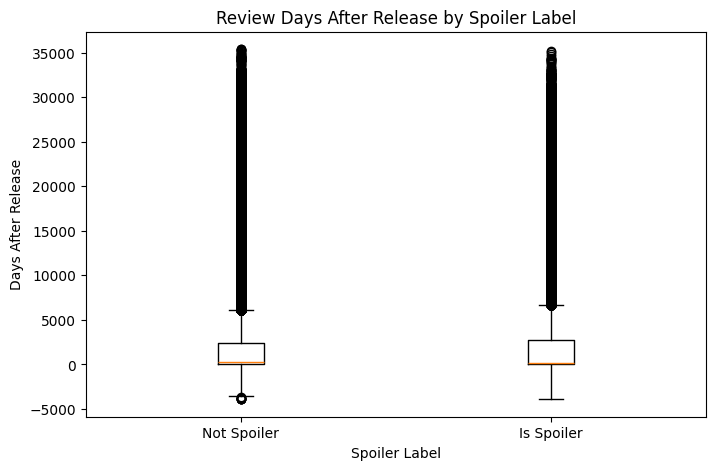

In [ ]:


not_spoiler = df_merged[df_merged["is_spoiler"] == 0]["review_days_after_released"].dropna()
is_spoiler = df_merged[df_merged["is_spoiler"] == 1]["review_days_after_released"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot([not_spoiler, is_spoiler], tick_labels=["Not Spoiler", "Is Spoiler"])
plt.xlabel("Spoiler Label")
plt.ylabel("Days After Release")
plt.title("Review Days After Release by Spoiler Label")
plt.show()

In [ ]:
df_merged[df_merged["review_days_after_released"] < 0][
    ["release_date", "review_date", "review_days_after_released"]
].head() #checking who can foresee the future

,release_date,review_date,review_days_after_released
62221,2002-10-03,1999-01-19,-1353.0
62231,2002-10-03,1999-08-17,-1143.0
62262,2002-10-03,1999-03-15,-1298.0
62263,2002-10-03,2001-10-02,-366.0
62280,2002-10-03,2001-05-20,-501.0


In [ ]:
df_merged.dtypes

,0
movie_id,object
plot_summary,object
duration,object
genre,object
movie_rating,float64
release_date,datetime64[ns]
plot_synopsis,object
review_date,datetime64[ns]
user_id,object
is_spoiler,object


In [ ]:
df_merged["review_length"]=df_merged["review_text"].astype(str).str.split().str.len()


In [ ]:
df_merged[["review_length", "user_rating", "is_spoiler"]].corr()["is_spoiler"] # check correlation for review text length and user rating against is_spolier

,is_spoiler
review_length,0.231844
user_rating,-0.088219
is_spoiler,1.000000


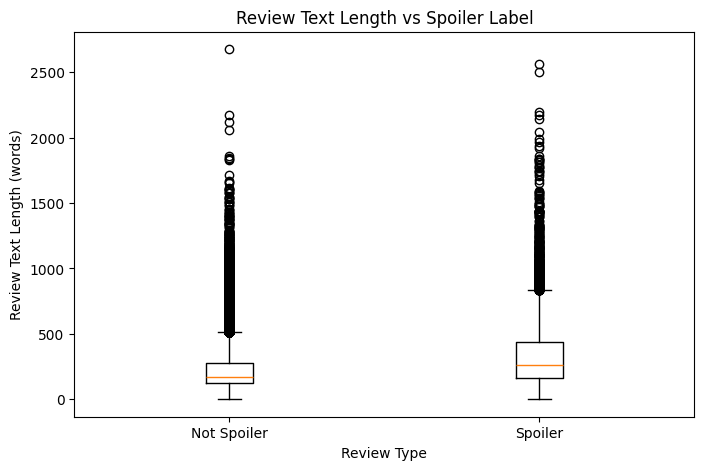

In [ ]:
not_spoiler_length = df_merged[df_merged["is_spoiler"] == 0]["review_length"]
spoiler_length = df_merged[df_merged["is_spoiler"] == 1]["review_length"]

plt.figure(figsize=(8, 5))
plt.boxplot([not_spoiler_length, spoiler_length], tick_labels=["Not Spoiler", "Spoiler"])
plt.xlabel("Review Type")
plt.ylabel("Review Text Length (words)")
plt.title("Review Text Length vs Spoiler Label")
plt.show()

Longer the text, more likely to contain spoiler

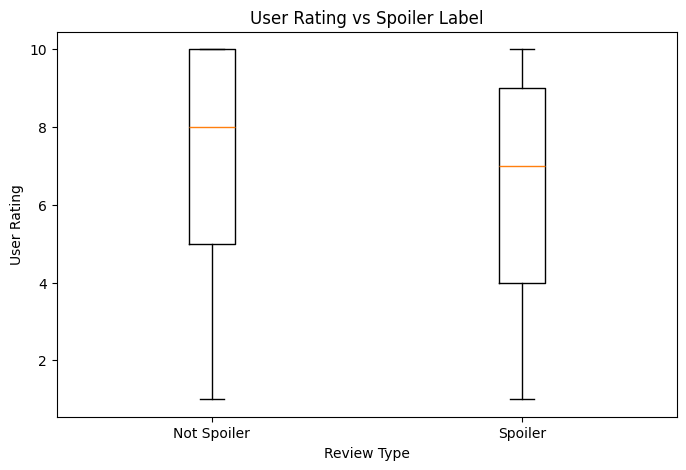

In [ ]:
not_spoiler_rating = df_merged[df_merged["is_spoiler"] == 0]["user_rating"]
spoiler_rating = df_merged[df_merged["is_spoiler"] == 1]["user_rating"]

plt.figure(figsize=(8, 5))
plt.boxplot([not_spoiler_rating, spoiler_rating], tick_labels=["Not Spoiler", "Spoiler"])
plt.xlabel("Review Type")
plt.ylabel("User Rating")
plt.title("User Rating vs Spoiler Label")
plt.show()

lower the rating, more likely to be spoiler

In [ ]:
df_merged['genre']


,genre
0,"[Comedy, Drama, Family]"
1,"[Comedy, Drama, Family]"
2,"[Comedy, Drama, Family]"
3,"[Comedy, Drama, Family]"
4,"[Comedy, Drama, Family]"
...,...
573910,[Romance]
573911,[Romance]
573912,[Romance]
573913,[Romance]


In [ ]:
df_merged["genre_combo"] = df_merged["genre"].apply(tuple)
genre_summary = df_merged.groupby("genre_combo").agg(
    spoiler_rate=("is_spoiler", "mean")
).sort_values("spoiler_rate", ascending=False)
genre_summary.head(10) #check the genre with most spoiler review

,spoiler_rate
genre_combo,
"(Adventure, Fantasy)",0.452414
"(Adventure, Mystery, Sci-Fi)",0.451613
"(Action, Drama, War)",0.407876
"(Action, Mystery, Sci-Fi)",0.394175
"(Fantasy, Mystery, Thriller)",0.393939
"(Romance,)",0.388889
"(Comedy, Horror, Thriller)",0.386628
"(Adventure, Sci-Fi, Thriller)",0.37995
"(Drama, Fantasy, Thriller)",0.379747


## Linear SVM Baseline Model

TF-IDF + LinearSVC for spoiler detection on `review_text`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)

In [ ]:
# Encode labels as integers and extract text feature
y = df_merged['is_spoiler'].astype(int)
X_text = df_merged['review_text'].astype(str)
print('Class distribution:')
print(y.value_counts())

In [ ]:
# Stratified 70/15/15 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_text, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

In [ ]:
# Fit TF-IDF on train only (prevents data leakage)
# ngram_range=(1,2): unigrams + bigrams; sublinear_tf dampens extreme frequencies
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                        sublinear_tf=True, min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'Train matrix shape: {X_train_tfidf.shape}')

In [ ]:
# LinearSVC is much faster than SVC(kernel='linear') at 500k rows
# CalibratedClassifierCV wraps it to enable predict_proba for ROC AUC
base_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(base_svm, cv=3)
svm_model.fit(X_train_tfidf, y_train)
print('Training complete.')

In [ ]:
# Evaluate on validation set
y_val_pred  = svm_model.predict(X_val_tfidf)
y_val_proba = svm_model.predict_proba(X_val_tfidf)[:, 1]

print('=== Validation Set ===')
print(classification_report(y_val, y_val_pred, target_names=['Non-Spoiler', 'Spoiler']))
print('ROC AUC:', roc_auc_score(y_val, y_val_proba))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred,
    display_labels=['Non-Spoiler', 'Spoiler'])
plt.title('Linear SVM - Validation Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Final evaluation on held-out test set (run once after validation tuning)
y_test_pred  = svm_model.predict(X_test_tfidf)
y_test_proba = svm_model.predict_proba(X_test_tfidf)[:, 1]

print('=== Test Set ===')
print(classification_report(y_test, y_test_pred, target_names=['Non-Spoiler', 'Spoiler']))
print('ROC AUC:', roc_auc_score(y_test, y_test_proba))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred,
    display_labels=['Non-Spoiler', 'Spoiler'])
plt.title('Linear SVM - Test Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Qualitative error analysis
fn_mask = (y_test == 1) & (y_test_pred == 0)  # missed spoilers
fp_mask = (y_test == 0) & (y_test_pred == 1)  # incorrectly flagged

fn_examples = X_test[fn_mask].reset_index(drop=True)
fp_examples = X_test[fp_mask].reset_index(drop=True)

print(f'False Negatives (missed spoilers): {fn_mask.sum():,}')
print(f'False Positives (incorrectly flagged): {fp_mask.sum():,}')

print('\n--- False Negatives (sample) ---')
for i, text in enumerate(fn_examples[:5]):
    print(f'[FN {i+1}] {text[:300]}\n')

print('--- False Positives (sample) ---')
for i, text in enumerate(fp_examples[:5]):
    print(f'[FP {i+1}] {text[:300]}\n')

### Error Analysis Observations

**False Negatives (missed spoilers):**
- Reviews that use vague or euphemistic language (e.g., "the ending surprised me") without naming specific plot events.
- Very short reviews where spoiler content is implied rather than stated.
- Spoilers embedded in otherwise positive praise, making them harder to detect by word frequency alone.

**False Positives (incorrectly flagged):**
- Reviews that discuss genre tropes or general plot structure without revealing specific events.
- Reviews referencing character names or settings that appear in spoiler-heavy vocabulary but in a non-revealing context.
- Highly detailed critical reviews that analyse film craft without disclosing plot outcomes.